In [1]:
from preprocessing.file_conversion import file_conversion
import numpy as np 

path = "/Users/reymendoza/Desktop/sleep_files"
X, X_scaled, y, groups = file_conversion(path)

Processing: sub-001_ses-001_task-sleep_acq-PSG_eeg.set
Reading /Users/reymendoza/Desktop/sleep_files/sub-001/ses-001/sub-001_ses-001_task-sleep_acq-PSG_eeg.fdt
Reading 0 ... 14255559  =      0.000 ... 28511.118 secs...
Creating RawArray with float64 data, n_channels=2, n_times=14255560
    Range : 0 ... 14255559 =      0.000 ... 28511.118 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)

  Feature matrix shape: (942, 50)
Processing: sub-001_ses-002_task-sleep_acq-PSG_ee

In [1]:
import numpy as np
#np.savez_compressed("sleep_dataset_20_6_2.npz", X=X, X_scaled=X_scaled, y=y, groups=groups)

data = np.load("/Users/reymendoza/Developer/Sleep-Stage-Classification/sleep_dataset_20_6_2.npz", allow_pickle=True)
X = data["X"]
X_scaled = data["X_scaled"]
y = data["y"]
groups = data["groups"]


Class counts:
1     4601
2     5478
3    21138
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.677
Name: proportion, dtype: float64

Fold 1/5
accuracy=0.7706, balanced_accuracy=0.7732, f1_macro=0.7109

Fold 2/5
accuracy=0.5958, balanced_accuracy=0.6768, f1_macro=0.5576

Fold 3/5
accuracy=0.8094, balanced_accuracy=0.8132, f1_macro=0.7725

Fold 4/5
accuracy=0.7427, balanced_accuracy=0.7089, f1_macro=0.6708

Fold 5/5
accuracy=0.7883, balanced_accuracy=0.7522, f1_macro=0.7345

Mean CV results:
accuracy: 0.7414
balanced_accuracy: 0.7449
precision_macro: 0.6809
recall_macro: 0.7449
f1_macro: 0.6893
precision_weighted: 0.8007
recall_weighted: 0.7414
f1_weighted: 0.7543
roc_auc_ovr_weighted: 0.8893

Classification report:
              precision    recall  f1-score   support

           1      0.490     0.867     0.626      4601
           2      0.591     0.617     0.604      5478
           3      0.904     0.742     0.815     21138

    accuracy                  

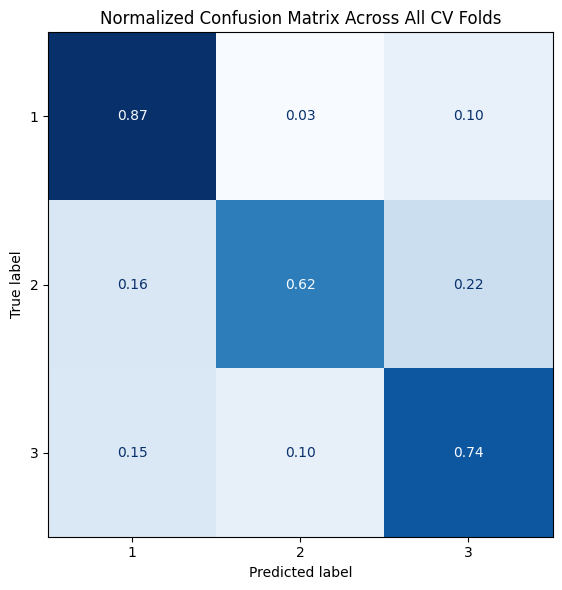

In [3]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model, build_xgb_model
from train import train, train_cnn, make_context_windows

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

model = build_xgb_model()

metrics = train(X, y, groups, model, smoothing=False, task='3-class')
show_metrics(metrics)


Class counts:
1     4601
2     5478
3     2504
4    13497
5     5137
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.080
4    0.432
5    0.165
Name: proportion, dtype: float64

Fold 1/5
accuracy=0.6770, balanced_accuracy=0.6700, f1_macro=0.6510

Fold 2/5
accuracy=0.5753, balanced_accuracy=0.5862, f1_macro=0.5353

Fold 3/5
accuracy=0.7875, balanced_accuracy=0.7206, f1_macro=0.7131

Fold 4/5
accuracy=0.6058, balanced_accuracy=0.6103, f1_macro=0.5768

Fold 5/5
accuracy=0.6481, balanced_accuracy=0.6022, f1_macro=0.5872

Mean CV results:
accuracy: 0.6587
balanced_accuracy: 0.6378
precision_macro: 0.6206
recall_macro: 0.6378
f1_macro: 0.6127
precision_weighted: 0.7092
recall_weighted: 0.6587
f1_weighted: 0.6668
roc_auc_ovr_weighted: 0.8915

Classification report:
              precision    recall  f1-score   support

           1      0.525     0.822     0.641      4601
           2      0.661     0.598     0.628      5478
           3      0.266     0.335     0.2

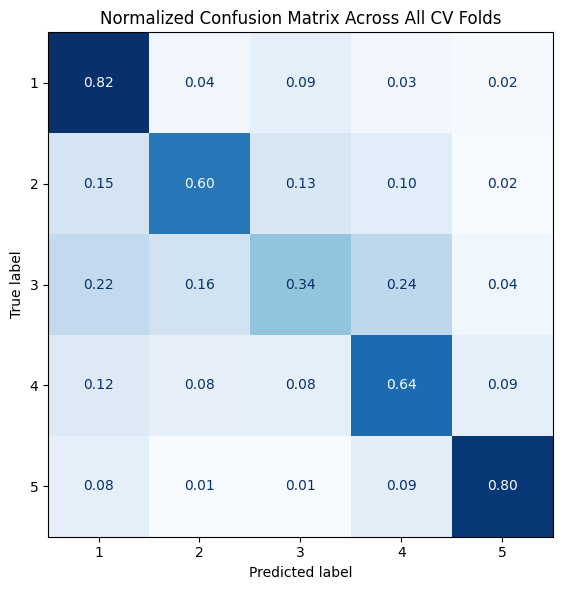

In [3]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model, build_xgb_model
from train import train, train_cnn, make_context_windows

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

model = build_xgb_model()

metrics = train(X, y, groups, model, task='5-class')
show_metrics(metrics)


Class counts:
1     4601
2     5478
3    21138
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.677
Name: proportion, dtype: float64

Fold 1/5
accuracy=0.7716, balanced_accuracy=0.7057, f1_macro=0.6810

Fold 2/5
accuracy=0.7251, balanced_accuracy=0.7199, f1_macro=0.6494

Fold 3/5
accuracy=0.8565, balanced_accuracy=0.8320, f1_macro=0.8177

Fold 4/5
accuracy=0.7977, balanced_accuracy=0.7365, f1_macro=0.7225

Fold 5/5
accuracy=0.8285, balanced_accuracy=0.7399, f1_macro=0.7642

Mean CV results:
accuracy: 0.7959
balanced_accuracy: 0.7468
precision_macro: 0.7365
recall_macro: 0.7468
f1_macro: 0.7270
precision_weighted: 0.8141
recall_weighted: 0.7959
f1_weighted: 0.7978
roc_auc_ovr_weighted: 0.9030

Classification report:
              precision    recall  f1-score   support

           1      0.603     0.840     0.702      4601
           2      0.676     0.547     0.605      5478
           3      0.879     0.848     0.863     21138

    accuracy                  

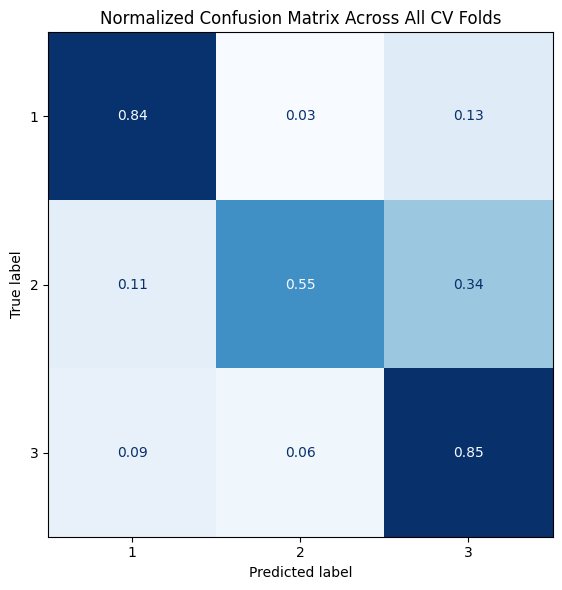

In [2]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model
from train import train, train_cnn, make_context_windows

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

model = build_rf_model()

metrics = train(X, y, groups, model, task='3-class')
show_metrics(metrics)


Class counts:
1     4601
2     5478
3     2504
4    13497
5     5137
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.175
3    0.080
4    0.432
5    0.165
Name: proportion, dtype: float64

Fold 1/5
accuracy=0.6784, balanced_accuracy=0.6482, f1_macro=0.6338

Fold 2/5
accuracy=0.6168, balanced_accuracy=0.5938, f1_macro=0.5567

Fold 3/5
accuracy=0.7742, balanced_accuracy=0.6897, f1_macro=0.6899

Fold 4/5
accuracy=0.6416, balanced_accuracy=0.6135, f1_macro=0.5900

Fold 5/5
accuracy=0.6559, balanced_accuracy=0.5796, f1_macro=0.5853

Mean CV results:
accuracy: 0.6734
balanced_accuracy: 0.6249
precision_macro: 0.6224
recall_macro: 0.6249
f1_macro: 0.6111
precision_weighted: 0.6922
recall_weighted: 0.6734
f1_weighted: 0.6724
roc_auc_ovr_weighted: 0.8862

Classification report:
              precision    recall  f1-score   support

           1      0.564     0.845     0.677      4601
           2      0.661     0.548     0.599      5478
           3      0.275     0.254     0.2

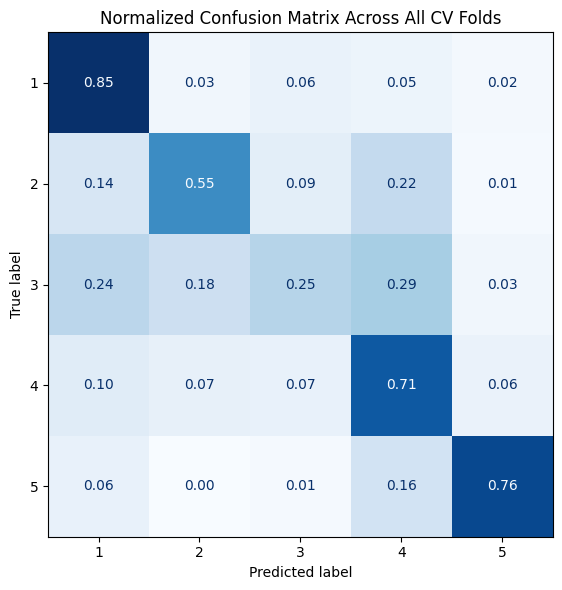

In [5]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model
from train import train, train_cnn, make_context_windows

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

model = build_rf_model()

metrics = train(X, y, groups, model, task='5-class')
show_metrics(metrics)

In [2]:
from metric_visualization import plot_normalized_confusion_matrix
from model import build_rf_model
from train import train, make_context_windows, train_hybrid_cnn_lstm_attention_smoothed

def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

metrics_h_3 = train_hybrid_cnn_lstm_attention_smoothed(X_scaled, X, y, groups, task='3-class')
show_metrics(metrics_h_3)


Class counts:
1     4568
2     5476
3    21133
Name: count, dtype: int64

Class proportions:
1    0.147
2    0.176
3    0.678
Name: proportion, dtype: float64

Fold 1/5


: 


Class counts:
1    2021
2    2441
3    1182
4    5757
5    1952
Name: count, dtype: int64

Class proportions:
1    0.151
2    0.183
3    0.089
4    0.431
5    0.146
Name: proportion, dtype: float64

Fold 1/5
Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 181s 527ms/step - accuracy: 0.3587 - loss: 1.4504 - val_accuracy: 0.5468 - val_loss: 1.1444 - learning_rate: 1.0000e-04
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 161s 499ms/step - accuracy: 0.4992 - loss: 1.1803 - val_accuracy: 0.5869 - val_loss: 1.0101 - learning_rate: 1.0000e-04
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 156s 485ms/step - accuracy: 0.5348 - loss: 1.0889 - val_accuracy: 0.6013 - val_loss: 0.9512 - learning_rate: 1.0000e-04
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 155s 481ms/step - accuracy: 0.5649 - loss: 1.0353 - val_accuracy: 0.6316 - val_loss: 0.9041 - learning_rate: 1.0000e-04
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 154s 479ms/step - accuracy: 0.5827 - loss: 0.9919 - val_accuracy: 0.6127 - val_loss: 0.9337 - learning_rate: 1.

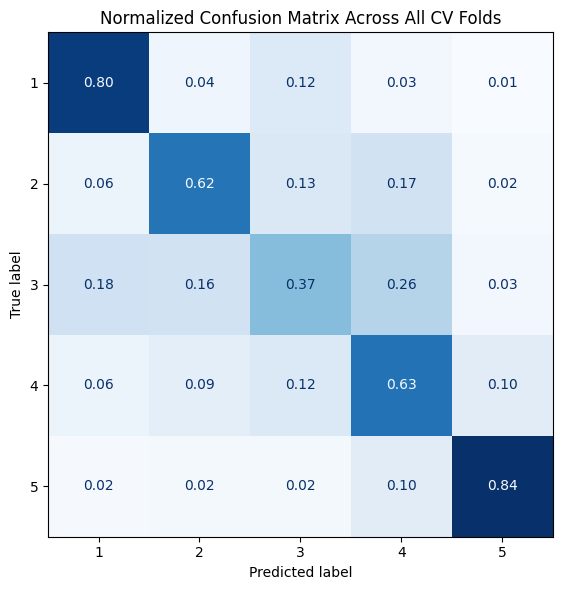

In [ ]:
def show_metrics(metrics):
    plot_normalized_confusion_matrix(
        cms=metrics["cms"],
        class_labels=metrics["class_labels"]
    )

metrics_h_5 = train_hybrid_cnn_lstm_attention_smoothed(X_scaled, X, y, groups, task='5-class')
show_metrics(metrics_h_5)